# EngiBench Tutorial

This is a basic tutorial showing how to use EngiBench and interact with problems.

Author: Florian Felten <ffelten@mavt.ethz.ch>

In [2]:
!pip install "engibench[all]"

  Cloning https://github.com/mdolab/pyoptsparse to /private/var/folders/fw/69hmbxm946l1xycg8w29nw0800l9gd/T/pip-install-sspoulap/pyoptsparse_fab6b0f907454f0f9b93f6d193a01da0
  Running command git clone --filter=blob:none --quiet https://github.com/mdolab/pyoptsparse /private/var/folders/fw/69hmbxm946l1xycg8w29nw0800l9gd/T/pip-install-sspoulap/pyoptsparse_fab6b0f907454f0f9b93f6d193a01da0
  Resolved https://github.com/mdolab/pyoptsparse to commit 61d8b83829ab23062be09a31fef5502007c31c50
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: pip install --upgrade pip


## Step 1: Instantiate a Problem

Let us see the Beam bending problem

In [3]:
from engibench.problems.beams2d.v0 import Beams2D

In [ ]:
problem = Beams2D(seed=9)

## Step 2: Inspect the Problem

### 2.1: Representation, Objectives, Boundary Conditions
The output just below means our beam is represented by 5000 pixels in `[0, 1]`. They are later reshaped as `(100, 50)`.

In [5]:
problem.design_space

Box(0.0, 1.0, (50, 100), float64)

In [6]:
problem.objectives

(('c', <ObjectiveDirection.MINIMIZE: 1>),)

In [7]:
problem.conditions

(('volfrac', 0.35),
 ('rmin', 2.0),
 ('forcedist', 0.0),
 ('overhang_constraint', False))

### 2.2 Data
We can directly access [the dataset linked to the problem](https://huggingface.co/datasets/IDEALLab/beams_2d_v0) doing the following:

In [8]:
problem.dataset

DatasetDict({
    train: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 3880
    })
    val: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 728
    })
    test: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 243
    })
})

## Step 3: Creating a Design and Launching the Simulator
While you usually would generate a design based on a generative or surrogate mode, we here show how to play with a rather random one.

In [9]:
my_design, idx = problem.random_design()
my_design.shape

(50, 100)

You can also render designs to see what they look like.

(<Figure size 800x400 with 2 Axes>, <Axes: >)

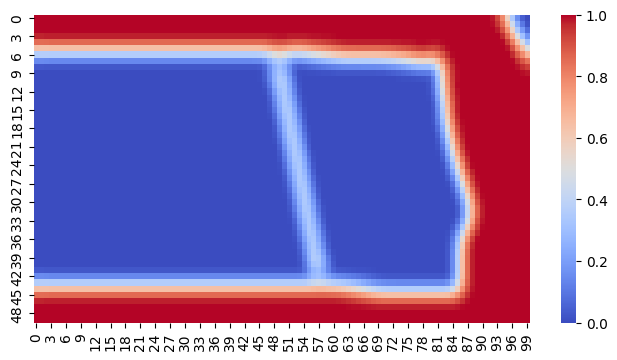

In [10]:
problem.render(my_design)

Now, we can check if the design, config pair is valid.

In [ ]:
config = {"volfrac": 0.3, "forcedist": 0.5}
violations = problem.check_constraints(my_design, config)
if violations:
    print("Violations found", violations)
else:
    print("No violations found")

Finally, you can:
- Simulate a design to get its objective values with `objs = problem.simulate(my_design)`
- Optimize a given design with `optimal_design, objs = problem.optimize(my_design)`

In [12]:
problem.simulate(my_design)

array([2463.819078])

In [ ]:
problem.reset(seed=0)
opt_design, opt_history = problem.optimize(my_design)
opt_history[-1]

ExtendedOptiStep(obj_values=array([278.44655728]), step=99, design=array([1., 1., 1., ..., 1., 1., 1.]))

Now let's see how different is the optimal design from our random design above.

(<Figure size 800x400 with 2 Axes>, <Axes: >)

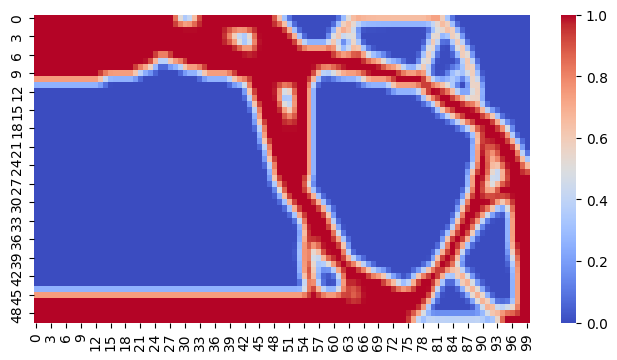

In [14]:
problem.render(opt_design)